In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from torch import nn
import os
from torch import nn
import copy
import matplotlib.pyplot as plt

from torch import optim
from torch.utils.data import random_split

import torch.nn.utils as utils
from torch.optim.lr_scheduler import OneCycleLR


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader

In [3]:
from tqdm import tqdm

In [4]:
class MoELayer(nn.Module):
    def __init__(self, input_dim, output_dim,aggregate_expert_hparam=1000,top_k=20,
                 calculated_to_noise_ratio = 1):
        super(MoELayer, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        #self.linear = nn.Linear(input_dim, output_dim)
        self.aggregate_hparam = aggregate_expert_hparam
        self.aggregate_expert_size = (self.aggregate_hparam)*(input_dim*output_dim)
        self.aggregate_expert_number = self.aggregate_expert_size//self.input_dim
        self.MoE_shape = (self.aggregate_expert_number,self.input_dim)
        self.mixture_experts = nn.Parameter(torch.nn.init.xavier_uniform_(torch.empty(self.MoE_shape)))
        self.top_K = top_k
        self.c2nr= calculated_to_noise_ratio
        
    def forward(self, x, calculated_to_noise_ratio):
        #print(x.shape,"Input shapee")
        #print(self.mixture_experts.shape,"all parameter shapes")
        scores = torch.einsum("ijk,lk->ijl", x, self.mixture_experts)
        scores = scores.reshape(x.shape[0], 150, self.output_dim, self.aggregate_hparam)
        score_softmax = torch.mean(scores, dim=2)
        
        softmax_output = torch.softmax(score_softmax, dim=2)
        #print(softmax_output.shape," Mixture of experts softmax shape")
        gaussian_tensor = torch.softmax(torch.randn(score_softmax.shape,device ="cuda"), dim=2)
        #print(gaussian_tensor.shape,gaussian_tensor.device," Shape of the made up gaussian tensor")
        # print("JJJJJDDDDDDD")
        # print(jd)
        # Making the routing noisy to pick different portions as the new data comes in
        #orignal_ratio = self.c2nr*softmax_output
        orignal_ratio = self.c2nr*softmax_output
      
        #print(gaussian_tensor.device,orignal_ratio.device,"DEVICES ################")
        noise = (1-self.c2nr)*gaussian_tensor
        softmax_output_final = orignal_ratio + noise
        #print(softmax_output_final.shape,"Final softmax output")
        #print(jfdhkashlkfa)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        topk_indices = torch.topk(softmax_output_final, self.top_K, dim=2).indices
        topk_indices = topk_indices.unsqueeze(-1)
        #print("Top k indices shape:", topk_indices.shape)  # torch.Size([3, 150, 5])
        #print(scores.shape,"Shape of scores")
        scores_ = scores.permute(0, 1, 3, 2)
        #print("Scores______",scores_.shape)
        scores_ = torch.gather(scores_, dim=2, index=topk_indices.expand(-1, -1, -1, self.output_dim))
        #print("SEMI SCORESSS", scores_.shape)
        output = torch.sum(scores_, dim=2)#.squeeze()
        #print("OUTPUTTTT FROM MOEEEEE #########", output.shape)
        #print(score_softmax.shape,"softmax scores")
        #print(softmax_output.shape,"After softmax")
        return output

class Digital_Twin_v1(nn.Module):
    def __init__(self, initial_state_dim, action_max_length, 
                 output_state_dim,pos_encoding_dims=3, hidden_dim = 64, c2nr = 1):
        super(Digital_Twin_v1, self).__init__()
        self.initial_state_dim = initial_state_dim
        self.action_max_length = action_max_length
        self.output_state_dim = output_state_dim
        self.pos_encoding_dims= pos_encoding_dims
        self.c2nr = c2nr
        self.positional_encoding = self.initialize_positional_encoding(pos_encoding_dims=self.pos_encoding_dims)

        self.embedding_layer = nn.Linear(self.pos_encoding_dims+initial_state_dim+2,hidden_dim)

        encoder_layer_1 = nn.TransformerEncoderLayer(d_model=64, nhead=2,
                                                     batch_first=True,dim_feedforward=256, dropout=0)
        self.encoder_1 = nn.TransformerEncoder(encoder_layer_1, num_layers=2)

        self.Moe_layer_1 = MoELayer(input_dim=64, output_dim=100, top_k =20,aggregate_expert_hparam=100)
        self.Moe_layer_12 = MoELayer(input_dim=100, output_dim=50, top_k =20,aggregate_expert_hparam=100)
        self.Moe_layer_13 = MoELayer(input_dim=10, output_dim=2, top_k =20,aggregate_expert_hparam=100)
        self.linear_final = nn.Linear(10,2)


        self.layer_norm1=nn.LayerNorm(100)
        self.layer_norm12=nn.LayerNorm(50)
        self.voltage_final_activation = nn.Tanh()

        self.temperature_final_activation = nn.Tanh()
        self.dropout_p = 0.15
        self.dropout_object = nn.Dropout(p=self.dropout_p)

        self.volt_lin_final1 =nn.Linear(50,30)
        self.volt_lin_final2 =nn.Linear(30,30)

        self.volt_lin_esti_1_mu = nn.Linear(30,30)
        self.volt_lin_esti_1_mu_trans = nn.TransformerEncoderLayer(d_model=30, nhead=2, batch_first=True, dim_feedforward= 128)
        self.volt_lin_esti_2_mu = nn.Linear(30,10)
        self.volt_lin_esti_2_mu_trans = nn.TransformerEncoderLayer(d_model=10, nhead=2, batch_first=True, dim_feedforward= 32)
        self.volt_lin_esti_3_mu = nn.Linear(10,1)

        self.volt_lin_esti_1_sigma = nn.Linear(30,30)
        self.volt_lin_esti_1_sigma_trans = nn.TransformerEncoderLayer(d_model=30, nhead=2, batch_first=True, dim_feedforward= 128)
        self.volt_lin_esti_2_sigma = nn.Linear(30,10)
        self.volt_lin_esti_2_sigma_trans = nn.TransformerEncoderLayer(d_model=10, nhead=2, batch_first=True, dim_feedforward= 32)
        self.volt_lin_esti_3_sigma = nn.Linear(10,1)


        self.temp_lin_final1 =nn.Linear(50,30)
        self.temp_lin_final2 =nn.Linear(30,30)
        
        self.temp_lin_esti_1_mu = nn.Linear(30,30)
        self.temp_lin_esti_1_mu_trans = nn.TransformerEncoderLayer(d_model=30, nhead=2, batch_first=True, dim_feedforward= 128)
        self.temp_lin_esti_2_mu = nn.Linear(30,10)
        self.temp_lin_esti_2_mu_trans = nn.TransformerEncoderLayer(d_model=10, nhead=2, batch_first=True, dim_feedforward= 32)
        self.temp_lin_esti_3_mu = nn.Linear(10,1)

        self.temp_lin_esti_1_sigma = nn.Linear(30,30)
        self.temp_lin_esti_1_sigma_trans = nn.TransformerEncoderLayer(d_model=30, nhead=2, batch_first=True, dim_feedforward= 128)
        self.temp_lin_esti_2_sigma = nn.Linear(30,10)
        self.temp_lin_esti_2_sigma_trans = nn.TransformerEncoderLayer(d_model=10, nhead=2, batch_first=True, dim_feedforward= 32)
        self.temp_lin_esti_3_sigma = nn.Linear(10,1)
        

        
    def forward(self, initial_state, action, inference_mode= False, no_ensembles=10):
        ## Define your forward pass here
        original_initial_state = initial_state.clone()
        batch_size = original_initial_state.shape[0]
        concatenated_features = self.input_processing(initial_state,action)
        positional_encoding_transformed = self.positional_encoding.unsqueeze(0).repeat(concatenated_features.shape[0],1,1)
        position_encoded_features = torch.cat((concatenated_features,positional_encoding_transformed),
                                              dim=2)
        
        ## Below we create an embedding.
        #print(position_encoded_features.shape,"Shape before embedding")
        #print(positional_encoding_transformed.shape, "<-Positional encoding", 
        embedding = self.embedding_layer(position_encoded_features)
        #print(embedding.shape,"Shape after embedding ")
        #print(embedding.shape,"#####")

        residual_1= self.encoder_1(embedding)
        #print(residual_1.shape,"SHAPE JUST AFTER TRANSFORMER ENCODING")

        residual_1 = self.Moe_layer_1(residual_1,calculated_to_noise_ratio=1)#.unsqueeze(0)
        residual_1 = self.layer_norm1(residual_1)
        residual_1 = torch.nn.functional.gelu(residual_1)
        residual_1 = self.Moe_layer_12(residual_1,calculated_to_noise_ratio=1)
        
        #residual_1 =self.linear_before_mode_selection(residual_1)

        if(inference_mode== False):
            #print(residual_1.shape,"SHAPE JUST AFTER 2 MOE LAYERS")
            residual_1 = self.layer_norm12(residual_1)
            residual_1 = torch.nn.functional.gelu(residual_1)
            #residual_1 = self.Moe_layer_13(residual_1,calculated_to_noise_ratio=1)

            residual_1_v =torch.nn.functional.gelu(self.volt_lin_final1(residual_1))
            residual_1_v =self.volt_lin_final2(residual_1_v)

            residual_1_t =torch.nn.functional.gelu(self.temp_lin_final1(residual_1))
            residual_1_t =self.temp_lin_final2(residual_1_t)
            
            #print(residual_1_v.shape, "Voltage shape to be processed shape")
            #print(residual_1_t.shape, "Temperature shape to be processed shape")
            residual_1_v_mu = torch.nn.functional.gelu(self.volt_lin_esti_1_mu(residual_1_v))
            residual_1_v_mu = self.volt_lin_esti_1_mu_trans(residual_1_v_mu)
            residual_1_v_mu = torch.nn.functional.gelu(self.volt_lin_esti_2_mu(residual_1_v_mu))
            residual_1_v_mu = self.volt_lin_esti_2_mu_trans(residual_1_v_mu)
            residual_1_v_mu = self.volt_lin_esti_3_mu(residual_1_v_mu)
            #print(residual_1_v_mu.shape,"SHAPE OF MU V")

            residual_1_v_sigma = torch.nn.functional.gelu(self.volt_lin_esti_1_sigma(residual_1_v))
            residual_1_v_sigma = self.volt_lin_esti_1_sigma_trans(residual_1_v_sigma)
            residual_1_v_sigma = torch.nn.functional.gelu(self.volt_lin_esti_2_sigma(residual_1_v_sigma))
            residual_1_v_sigma = self.volt_lin_esti_2_sigma_trans(residual_1_v_sigma)
            residual_1_v_sigma = self.volt_lin_esti_3_sigma(residual_1_v_sigma).squeeze()
            #print(residual_1_v_mu.shape,"SHAPE OF SIGMA V")

            #########################TEMPERATURE BRANCH BELOW##########################

            residual_1_t_mu = torch.nn.functional.gelu(self.temp_lin_esti_1_mu(residual_1_t))
            residual_1_t_mu = self.temp_lin_esti_1_mu_trans(residual_1_t_mu)
            residual_1_t_mu = torch.nn.functional.gelu(self.temp_lin_esti_2_mu(residual_1_t_mu))
            residual_1_t_mu = self.temp_lin_esti_2_mu_trans(residual_1_t_mu)
            residual_1_t_mu = self.temp_lin_esti_3_mu(residual_1_t_mu)
            #print(residual_1_t_mu.shape,"SHAPE OF MU T")

            residual_1_t_sigma = torch.nn.functional.gelu(self.temp_lin_esti_1_sigma(residual_1_t))
            residual_1_t_sigma = self.temp_lin_esti_1_sigma_trans(residual_1_t_sigma)
            residual_1_t_sigma = torch.nn.functional.gelu(self.temp_lin_esti_2_sigma(residual_1_t_sigma))
            residual_1_t_sigma = self.temp_lin_esti_2_sigma_trans(residual_1_t_sigma)
            residual_1_t_sigma = self.temp_lin_esti_3_sigma(residual_1_t_sigma).squeeze()
            #print(residual_1_v_mu.shape,"SHAPE OF SIGMA T")



            
            voltage_mu_prediction = residual_1_v_mu

            voltage_error_prediction  = torch.exp(residual_1_v_sigma)#.unsqueeze(dim=-1))
            voltage_error_prediction = torch.clamp(voltage_error_prediction, min=0, max=50)

            #print("OLD Voltage mu,sigma",voltage_mu_prediction.shape,voltage_error_prediction.shape)
            temp_mu_prediction =residual_1_t_mu
            temp_error_prediction  = torch.exp(residual_1_t_sigma)#.unsqueeze(dim=-1))
            temp_error_prediction = torch.clamp(temp_error_prediction, min=0, max=50)

            #print("Temp mu,sigma",temp_mu_prediction.shape,temp_error_prediction.shape)
            #print(residual_1_t.shape, "Temperature shape")
            #print(djlakjs)
            
            repeated_original_initial_state = original_initial_state.unsqueeze(1).repeat(1, action.size(1), 1)

            repeated_original_voltage = repeated_original_initial_state[:,:,1]
            repeated_original_temperature = repeated_original_initial_state[:,:,2]
            #print(repeated_original_voltage.shape,"REPEATED VOLTAGE SHAPE")
            #print(repeated_original_temperature.shape,"REPEATED TEMPERATURE SHAPE")
            #print(jd)
            #print(repeated_original_temperature.shape,":<- Repeated temperature", repeated_original_voltage.shape,"<-Voltage shape")
            predicted_states_voltage = repeated_original_voltage + voltage_mu_prediction.squeeze(dim=2) #+ residual_2_voltage #+residual_3_voltage
            predicted_states_temperature = repeated_original_temperature + temp_mu_prediction.squeeze(dim=2) #+ residual_2_temperature #+ residual_3_temperature
            #print(predicted_states_voltage.shape,predicted_states_temperature.shape," Volt, Temp shapes")
            
            predicted_mu_sigma_final = torch.stack((predicted_states_voltage, predicted_states_temperature,voltage_error_prediction,temp_error_prediction), dim=2)
            return predicted_mu_sigma_final
        else:
            pass

    def forward_per_scale(self, initial_state, action,  
                          scale, scaling_factor, previous_residual):

        return None
    
    def initialize_positional_encoding(self,pos_encoding_dims=4):
        
        positional_encoding = torch.arange(self.action_max_length)
        positional_encoding = positional_encoding.unsqueeze(1).repeat(1,pos_encoding_dims)

        denominator_exponent_array = torch.arange(pos_encoding_dims)
        denominator_exponent_array = (2*(denominator_exponent_array//2)/pos_encoding_dims)
        denominator = torch.pow(self.action_max_length,denominator_exponent_array )
        inputs_before_function = positional_encoding/denominator
        positional_encoding_ = torch.full_like(inputs_before_function,-1)
        positional_encoding_[:,0::2] = torch.sin(inputs_before_function[:,0::2])
        positional_encoding_[:,1::2] = torch.cos(inputs_before_function[:,1::2])
        
        return positional_encoding_
    
    def input_processing(self,initial_state, action):
        
        #print(initial_state.shape,action.shape,"Inputs shape")
        original_initial_state = initial_state.clone() #So that original value does not change
        original_initial_state[:,0] = original_initial_state[:,0]*10 ## Normalization for resistance
        original_initial_state[:,1] = original_initial_state[:,1]/3 #Voltage Normalization
        original_initial_state[:,2] = original_initial_state[:,2]/30 #Current Normalization
        original_actions = action.clone() #So that original value does not change

        original_actions = original_actions/5 #Normalization
        
        actions_clone_1= action.clone()
        actions_clone_2= action.clone()
        actions_delta_shifted = actions_clone_2
        actions_delta_shifted[:,1:,:]-=actions_clone_1[:,0:-1,:] ## We capture increase every t
        actions_delta_shifted[:,0,:] = 0


        modified_initial_state = original_initial_state.unsqueeze(1).repeat(1,original_actions.shape[1],1)
        concatenated_features = torch.cat((modified_initial_state,actions_delta_shifted,original_actions), dim=2)

        return concatenated_features


In [5]:
path= '../../Capacity_prediction/Log_files/Log_files/cell_log_age_2s_P065_1_S01_C03.csv'
df = pd.read_csv(path,sep=';')
df.head(10)

,timestamp_s,v_raw_V,ocv_est_V,i_raw_A,t_cell_degC,soc_est,delta_q_Ah,EFC,cap_aged_est_Ah,R0_mOhm,R1_mOhm
0,5700,3.5516,3.5521,0.0008,24.99,26.51,0.0,0.0,NaN,NaN,NaN
1,5702,3.5521,3.5521,-0.0003,24.99,26.51,0.0,0.0,NaN,NaN,NaN
2,5704,3.5520,3.5521,0.0004,24.99,26.51,0.0,0.0,NaN,NaN,NaN
3,5706,3.5522,3.5521,0.0001,24.99,26.51,0.0,0.0,NaN,NaN,NaN
4,5708,3.5523,3.5521,0.0008,24.98,26.51,0.0,0.0,NaN,NaN,NaN
5,5710,3.5517,3.5521,-0.0010,24.99,26.51,0.0,0.0,NaN,NaN,NaN
6,5712,3.5523,3.5521,-0.0003,24.98,26.51,0.0,0.0,NaN,NaN,NaN
7,5714,3.5521,3.5521,0.0001,24.98,26.51,0.0,0.0,NaN,NaN,NaN
8,5716,3.5523,3.5521,0.0004,24.99,26.51,0.0,0.0,NaN,NaN,NaN
9,5718,3.5524,3.5521,0.0011,24.98,26.51,0.0,0.0,NaN,NaN,NaN


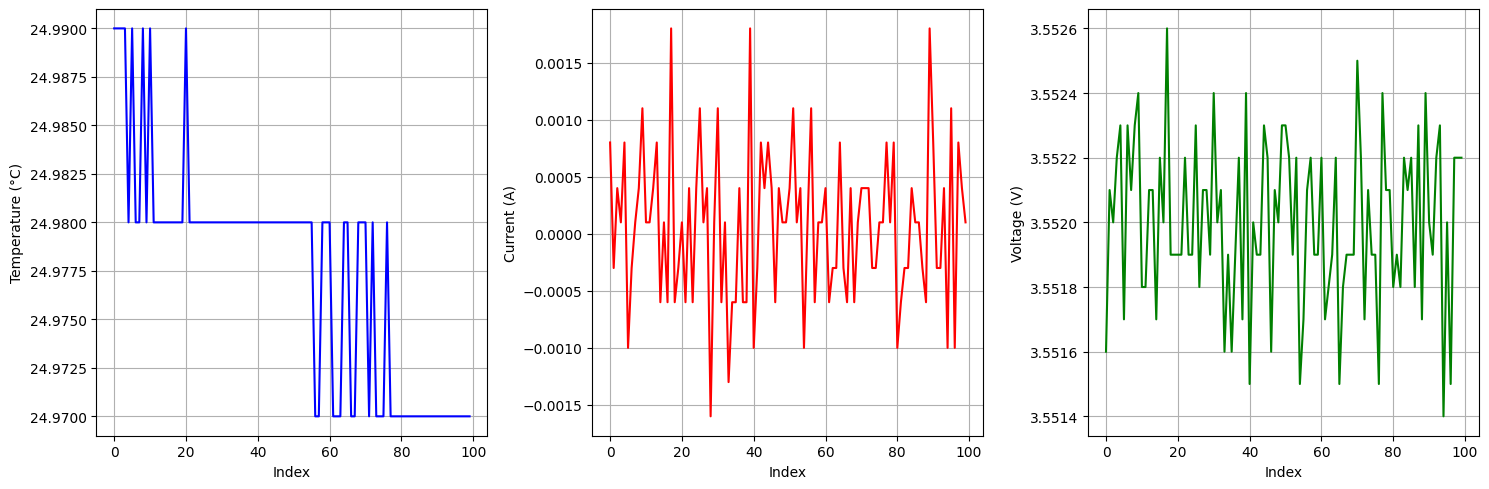

In [6]:
# Create figure with three subplots arranged horizontally (1 row, 3 columns)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# Define the range
start = 0
ending = 100

# First subplot (t_cell_degC)
ax1.plot(df['t_cell_degC'][start:ending], color='blue')
ax1.set_title('')  # Empty title
ax1.set_xlabel('Index')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True)

# Second subplot (i_raw_A)
ax2.plot(df['i_raw_A'][start:ending], color='red')
ax2.set_title('')  # Empty title
ax2.set_xlabel('Index')
ax2.set_ylabel('Current (A)')
ax2.grid(True)

# Third subplot (v_raw_V)
ax3.plot(df['v_raw_V'][start:ending], color='green')
ax3.set_title('')  # Empty title
ax3.set_xlabel('Index')
ax3.set_ylabel('Voltage (V)')
ax3.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [7]:
# Create relative_age column with linear interpolation from 0 to 1
df['relative_age'] = np.linspace(0, 1, len(df))

In [8]:
# Step 1: Calculate delV and delI
df['delV'] = df['v_raw_V'].diff()
df['delI'] = df['i_raw_A'].diff()

# Replace exact 0 in delI with NaN
df.loc[df['delI'] == 0, 'delI'] = np.nan

# Step 2: Calculate delV/delI
df['delV_delI'] = df['delV'] / df['delI']

# Step 3: Fill delV/delI for rows where delI was NaN with previous non-NaN
df['delV_delI'] = df['delV_delI'].fillna(method='ffill')

# Step 4: Backfill first row's NaN (since diff creates NaN in first row)
df['delV_delI'] = df['delV_delI'].fillna(method='bfill')


/tmp/ipykernel_34021/781649033.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['delV_delI'] = df['delV_delI'].fillna(method='ffill')
/tmp/ipykernel_34021/781649033.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['delV_delI'] = df['delV_delI'].fillna(method='bfill')


### Some notes about below processing 
1. Accurately reflects the actual conditions of discrete measurements but continous control. 
2. Time is not captured as resolution invariant predictions require extra engineering which will be done later after first iteration. 
3. This also implies some kind of slack when evaluation of the predictions. 

In [9]:
# Convert DataFrame to tensors
data_2 = df.copy()
sequence_length_2 = 76  # Changed to 76 for initial chunks

# Create sequences of length 76 with no overlap
n_sequences_2 = len(data_2) // sequence_length_2
data_2 = data_2.iloc[:n_sequences_2*sequence_length_2]  # Truncate to make it divisible by sequence_length_2

# Prepare input sequences
states_2 = []
currents_2 = []
voltage_targets_2 = []
temp_targets_2 = []

for i in tqdm(range(0, len(data_2), sequence_length_2), desc="Creating sequences"):
    chunk_2 = data_2.iloc[i:i+sequence_length_2]
    
    # Initial state for this sequence
    init_state_2 = torch.tensor([[
        chunk_2.iloc[0].relative_age,
        chunk_2.iloc[0].v_raw_V, 
        chunk_2.iloc[0].t_cell_degC
    ]], dtype=torch.float32, device='cuda')
    states_2.append(init_state_2)
    
    # Current input sequence - duplicate each value and remove first/last
    current_seq_2 = torch.tensor(chunk_2.i_raw_A.values, dtype=torch.float32, device='cuda')
    curr_numpy = chunk_2.i_raw_A.values
    curr_interp = np.zeros(2*len(curr_numpy)-1)
    curr_interp[::2]=curr_numpy
    curr_interp[1::2]=np.nan
    curr_interp = pd.Series(curr_interp).interpolate().values
    curr_interp = curr_interp[1:]
    
    current_seq_2 = torch.tensor(curr_interp, dtype=torch.float32, device='cuda')
    current_seq_2 = current_seq_2.view(1, 150, 1)
    currents_2.append(current_seq_2)
    
    # Target sequences with interpolation
    voltage_vals_2 = chunk_2.v_raw_V.values
    temp_vals_2 = chunk_2.t_cell_degC.values
    
    # Interpolate between values
    # Create arrays with NaN between every 2 elements
    voltage_interp_2 = np.zeros(2*len(voltage_vals_2)-1)
    temp_interp_2 = np.zeros(2*len(temp_vals_2)-1)
    
    voltage_interp_2[::2] = voltage_vals_2
    temp_interp_2[::2] = temp_vals_2
   
    voltage_interp_2[1::2] = np.nan
    temp_interp_2[1::2] = np.nan
    
    # Interpolate NaN values
    voltage_interp_2 =pd.Series(voltage_interp_2).interpolate().values  # Fill NaN values with previous value
    temp_interp_2 = pd.Series(temp_interp_2).interpolate().values
    
    # Remove first value to get length 150
    voltage_interp_2 = voltage_interp_2[1:]
    temp_interp_2 = temp_interp_2[1:]
    
    voltage_targets_2.append(torch.tensor(voltage_interp_2, dtype=torch.float32, device='cuda'))
    temp_targets_2.append(torch.tensor(temp_interp_2, dtype=torch.float32, device='cuda'))
    
# Convert lists of tensors to single tensors by concatenating along batch dimension
states_2 = torch.cat(states_2, dim=0)  # Shape: [n_sequences_2, 1, 3]
currents_2 = torch.cat(currents_2, dim=0)  # Shape: [n_sequences_2, sequence_length_2, 1]
voltage_targets_2 = torch.stack(voltage_targets_2, dim=0)  # Shape: [n_sequences_2, sequence_length_2] 
temp_targets_2 = torch.stack(temp_targets_2, dim=0)  # Shape: [n_sequences_2, sequence_length_2]


Creating sequences: 100%|██████████| 199097/199097 [02:12<00:00, 1504.70it/s]


In [10]:
# # Example assuming your tensors are already defined
# tensors = {
#     "states_2": states_2,
#     "currents_2": currents_2,
#     "voltage_targets_2": voltage_targets_2,
#     "temp_targets_2": temp_targets_2,
# }

# total_mib = 0
# for name, t in tensors.items():
#     num_bytes = t.numel() * t.element_size()  # total bytes
#     mib = num_bytes / (1024 ** 2)  # convert to MiB
#     total_mib += mib
#     print(f"{name:20s} shape={tuple(t.shape)}, memory={mib:.3f} MiB")

# print(f"Total memory: {total_mib:.3f} MiB")


In [11]:

class BatteryDataset(Dataset):
    def __init__(self, states_2, currents_2, voltage_targets_2, temp_targets_2):
        self.states_2 = states_2
        self.currents_2 = currents_2
        self.voltage_targets_2 = voltage_targets_2
        self.temp_targets_2 = temp_targets_2
        self.length = states_2.shape[0]  # number of sequences

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        state = self.states_2[idx]                     # shape: (3,)
        current = self.currents_2[idx]                 # shape: (150, 1)
        
        # Concatenate voltage + temp along last dim -> (150, 2)

        vt_concat = torch.stack(
            [self.voltage_targets_2[idx], self.temp_targets_2[idx]], dim=-1
        )
        
        
        return state, current, vt_concat

# Create dataset
dataset = BatteryDataset(states_2, currents_2, voltage_targets_2, temp_targets_2)

# Create DataLoader
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Example: fetch one batch
for batch_states, batch_currents, batch_vt in loader:
    print("states:", batch_states.shape)   
    print("currents:", batch_currents.shape) 
    print("voltage+temp:", batch_vt.shape)  
    break


states: torch.Size([64, 3])
currents: torch.Size([64, 150, 1])
voltage+temp: torch.Size([64, 150, 2])


In [12]:

# class BatteryDataset_Optimised(Dataset):
#     def __init__(self, dataset=df.copy()):
#         self.dataset = dataset
#         self.sequence_length = 76
#         self.number_sequences = len(self.dataset)-self.sequence_length-10


#     def __len__(self):
#         return self.number_sequences

#     def __getitem__(self, idx):
#         i = idx
#         chunk_2 = self.dataset.iloc[i:i+self.sequence_length]
        
#         # Initial state for this sequence
#         init_state_2 = torch.tensor([[
#             chunk_2.iloc[0].relative_age,
#             chunk_2.iloc[0].v_raw_V, 
#             chunk_2.iloc[0].t_cell_degC
#         ]], dtype=torch.float32, device='cuda')
        
#         # Current input sequence - duplicate each value and remove first/last
#         current_seq_2 = torch.tensor(chunk_2.i_raw_A.values, dtype=torch.float32, device='cuda')
#         curr_numpy = chunk_2.i_raw_A.values
#         curr_interp = np.zeros(2*len(curr_numpy)-1)
#         curr_interp[::2]=curr_numpy
#         curr_interp[1::2]=np.nan
#         curr_interp = pd.Series(curr_interp).interpolate().values
#         curr_interp = curr_interp[1:]
        
#         current_seq_2 = torch.tensor(curr_interp, dtype=torch.float32, device='cuda')
#         current_seq_2 = current_seq_2.view(1, 150, 1)
#         # Logic is that just after observing previous seconds value we are then inputting and immediately observing. 
#         # Target sequences with interpolation
#         voltage_vals_2 = chunk_2.v_raw_V.values
#         temp_vals_2 = chunk_2.t_cell_degC.values
        
#         # Interpolate between values
#         # Create arrays with NaN between every 2 elements
#         voltage_interp_2 = np.zeros(2*len(voltage_vals_2)-1)
#         temp_interp_2 = np.zeros(2*len(temp_vals_2)-1)
        
#         voltage_interp_2[::2] = voltage_vals_2
#         temp_interp_2[::2] = temp_vals_2
    
#         voltage_interp_2[1::2] = np.nan
#         temp_interp_2[1::2] = np.nan
        
#         # Interpolate NaN values
#         voltage_interp_2 =pd.Series(voltage_interp_2).interpolate().values  # Fill NaN values with previous value
#         temp_interp_2 = pd.Series(temp_interp_2).interpolate().values
        
#         # Remove first value to get length 150
#         voltage_interp_2 = voltage_interp_2[1:]
#         temp_interp_2 = temp_interp_2[1:]               # shape: (150, 1)
        
#         voltage_tensor = torch.tensor(voltage_interp_2, dtype=torch.float32, device='cuda')
#         temp_tensor = torch.tensor(temp_interp_2, dtype=torch.float32, device='cuda')
#         # Concatenate voltage + temp along last dim -> (150, 2)

#         vt_concat = torch.stack(
#             [voltage_tensor, voltage_tensor], dim=-1
#         )
        
        
#         return init_state_2.squeeze(dim=0), current_seq_2.squeeze(dim=0), vt_concat

# # Create dataset
# dataset_opt = BatteryDataset_Optimised(dataset=df.copy())

# # Create DataLoader
# loader = DataLoader(dataset_opt, batch_size=64, shuffle=True)

# # Example: fetch one batch
# for batch_states, batch_currents, batch_vt in loader:
#     print("states:", batch_states.shape)   
#     print("currents:", batch_currents.shape) 
#     print("voltage+temp:", batch_vt.shape)  
#     break


In [ ]:
from torch.utils.data import Subset

train_indices = []
val_indices = []
test_indices = []

group_size = 5
dataset_selected = dataset
n = len(dataset_selected)

for i in range(0, n, group_size):
    group = list(range(i, min(i + group_size, n)))
    if len(group) == group_size:  # only full groups
        train_indices.extend(group[:3])  # first 3
        val_indices.append(group[3])     # 4th
        test_indices.append(group[4])    # 5th


train_set = Subset(dataset_selected, train_indices)
val_set = Subset(dataset_selected, val_indices)
test_set = Subset(dataset_selected, test_indices)


In [14]:
batch_size_ = 64*4
train_loader = DataLoader(train_set, batch_size=batch_size_, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size_, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size_, shuffle=False)


In [15]:
print(len(train_set), len(train_loader))

119457 467


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device, scheduler= None):
    model.train()
    running_loss = 0.0
    running_v_mape = 0.0
    running_t_mape = 0.0
    running_max_v_mape =torch.tensor(float('-inf'))
    running_max_t_mape = torch.tensor(float('-inf'))
    
    running_vc_mape = 0.0
    running_tc_mape = 0.0
    running_max_vc_mape = torch.tensor(float('-inf'))
    running_max_tc_mape = torch.tensor(float('-inf'))


    num_batch_counter = 0

    for states, currents, vt_concat in tqdm(loader, desc="Training", leave=False):
        states = states.to(device)#.float()       
        currents = currents.to(device)#.float()   
        targets = vt_concat.to(device)#.float()   
        optimizer.zero_grad()
        outputs = model(states, -1*currents)
        predicted_vt_values = outputs[...,:2] 
        
        voltage_mu_output = predicted_vt_values[...,0]
        temperature_mu_output = predicted_vt_values[...,1]
        mu_scaling = torch.mean(torch.abs(voltage_mu_output/temperature_mu_output))
        
        voltage_targets = targets[...,0]
        temperature_targets = targets[...,1]
        
        voltage_loss = criterion(voltage_mu_output[:,1::2],voltage_targets[:,1::2])
        temperature_loss = criterion(temperature_mu_output[:,1::2],temperature_targets[:,1::2])
        mu_loss = voltage_loss + (temperature_loss*(mu_scaling))

        
        
        predicted_vt_confidence = outputs[...,2:] 
        voltage_confidence_output = predicted_vt_confidence[...,0]
        temperature_confidence_output = predicted_vt_confidence[...,1]

        true_confidence_voltage = torch.abs(voltage_mu_output-voltage_targets)
        true_confidence_temperature = torch.abs(temperature_mu_output-temperature_targets)
        
        voltage_confidence_loss = criterion(voltage_confidence_output[:,1::2],
                                             true_confidence_voltage[:,1::2])
        
        temperature_confidence_loss = criterion(temperature_confidence_output[:,1::2],
                                             true_confidence_temperature[:,1::2])
        
        confidence_scaling = torch.mean(torch.abs(voltage_confidence_output/temperature_confidence_output))
        confidence_loss = voltage_confidence_loss + (temperature_confidence_loss*(confidence_scaling))


        final_scaling = (mu_loss/confidence_loss)
        
        loss_final = mu_loss+(confidence_loss*(final_scaling))
        loss_final.backward()
        utils.clip_grad_norm_(model.parameters(), max_norm=2)
        if scheduler is not None:
            scheduler.step()

        optimizer.step() 
        running_loss +=(loss_final.item())* states.size(0)


        voltage_mape_arr = 100*(torch.abs((voltage_mu_output[:,1::2].clone().detach()-voltage_targets[:,1::2].clone().detach())/(voltage_targets[:,1::2].clone().detach())))
        temperature_mape_arr = 100*(torch.abs((temperature_mu_output[:,1::2].clone().detach()-temperature_targets[:,1::2].clone().detach())/(temperature_targets[:,1::2].clone().detach())))
        max_voltage_mape = voltage_mape_arr.max().item()
        max_temperature_mape = temperature_mape_arr.max().item()
        

        # voltage_confidence_mape_arr = 100*(torch.abs((voltage_confidence_output[:,1::2].clone().detach()-true_confidence_voltage[:,1::2].clone().detach())/(true_confidence_voltage[:,1::2].clone().detach())))
        # temperature_confidence_mape_arr = 100*(torch.abs((temperature_confidence_output[:,1::2].clone().detach()-true_confidence_temperature[:,1::2].clone().detach())/(true_confidence_temperature[:,1::2].clone().detach())))
        
        ### THE BELOW IS NOT MAPE CALCULATION BUT MAE. THE NAMING IS NOT DISTUREBED FOR CONVENTION AND CONVINIENCE.
        voltage_confidence_mape_arr = (torch.abs((voltage_confidence_output[:,1::2].clone().detach()-true_confidence_voltage[:,1::2].clone().detach())))
        temperature_confidence_mape_arr = (torch.abs((temperature_confidence_output[:,1::2].clone().detach()-true_confidence_temperature[:,1::2].clone().detach())))


        max_voltage_confidence_mape = voltage_confidence_mape_arr.max().item()
        max_temperature_confidence_mape = temperature_confidence_mape_arr.max().item()

        voltage_mape =torch.mean(voltage_mape_arr)
        temperature_mape = torch.mean(temperature_mape_arr)

        voltage_confidence_mape =torch.mean(voltage_confidence_mape_arr)
        temperature_confidence_mape = torch.mean(temperature_confidence_mape_arr)


        num_batch_counter +=1
        running_v_mape += voltage_mape
        running_t_mape +=temperature_mape
        running_vc_mape +=voltage_confidence_mape
        running_tc_mape += temperature_confidence_mape
        ### KEEPING TRACK OF THE WORST BEHAVIOUR BELOW 
        if(max_voltage_mape>running_max_v_mape):
            running_max_v_mape = max_voltage_mape
        else: 
            pass

        if(max_temperature_mape>running_max_t_mape):
            running_max_t_mape = max_temperature_mape
        else:
            pass

        if(max_voltage_confidence_mape>running_max_vc_mape):
            running_max_vc_mape = max_voltage_confidence_mape
        else:
            pass

        if(max_temperature_confidence_mape>running_max_tc_mape):
            running_max_tc_mape = max_temperature_confidence_mape
        else:
            pass
    
    ########## AVERAGING QUANTITIES AFTER TRAINING LOOP COMPLETION. 
    final_total_loss = running_loss / len(loader.dataset)
    final_voltage_mape = running_v_mape.item()/num_batch_counter
    final_temperature_mape = running_t_mape.item()/num_batch_counter
    final_vc_mape = running_vc_mape.item()/num_batch_counter
    final_tc_mape = running_tc_mape.item()/num_batch_counter

    return final_total_loss, final_voltage_mape, final_temperature_mape, running_max_v_mape,running_max_t_mape, final_vc_mape,final_tc_mape, running_max_vc_mape, running_max_tc_mape


In [17]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_mu_loss = 0.0
    running_v_mape = 0.0
    running_t_mape = 0.0
    running_max_v_mape =torch.tensor(float('-inf'))
    running_max_t_mape = torch.tensor(float('-inf'))
    
    running_vc_mape = 0.0
    running_tc_mape = 0.0
    running_max_vc_mape = torch.tensor(float('-inf'))
    running_max_tc_mape = torch.tensor(float('-inf'))

    num_batch_counter = 0

    with torch.no_grad():
        for states, currents, vt_concat in tqdm(loader, desc="Validation", leave=False):
            states = states.to(device).float()
            currents = currents.to(device).float()
            targets = vt_concat.to(device).float()

            outputs = model(states, -1*currents)
            predicted_vt_values = outputs[...,:2] 
            
            voltage_mu_output = predicted_vt_values[...,0]
            temperature_mu_output = predicted_vt_values[...,1]

            voltage_targets = targets[...,0]
            temperature_targets = targets[...,1]


            predicted_vt_confidence = outputs[...,2:] 
            voltage_confidence_output = predicted_vt_confidence[...,0]
            temperature_confidence_output = predicted_vt_confidence[...,1]

            true_confidence_voltage = torch.abs(voltage_mu_output-voltage_targets)
            true_confidence_temperature = torch.abs(temperature_mu_output-temperature_targets)
            
            mu_scaling = torch.mean(torch.abs(voltage_mu_output/temperature_mu_output))
            voltage_loss = criterion(voltage_mu_output[:,1::2],voltage_targets[:,1::2])
            temperature_loss = criterion(temperature_mu_output[:,1::2],temperature_targets[:,1::2])
            mu_loss = voltage_loss + (temperature_loss*(mu_scaling))
            running_mu_loss += (mu_loss.item())*states.size(0)


        

            predicted_vt_confidence = outputs[...,2:] 
            voltage_confidence_output = predicted_vt_confidence[...,0]
            temperature_confidence_output = predicted_vt_confidence[...,1]
            confidence_scaling = torch.mean(torch.abs(voltage_confidence_output/temperature_confidence_output))

            voltage_mape_arr = 100*(torch.abs((voltage_mu_output[:,1::2]-voltage_targets[:,1::2])/(voltage_targets[:,1::2])))
            temperature_mape_arr = 100*(torch.abs((temperature_mu_output[:,1::2]-temperature_targets[:,1::2])/(temperature_targets[:,1::2])))
            max_voltage_mape = voltage_mape_arr.max().item()
            max_temperature_mape = temperature_mape_arr.max().item()


            voltage_confidence_mape_arr = 100*(torch.abs((voltage_confidence_output[:,1::2]-true_confidence_voltage[:,1::2])))
            temperature_confidence_mape_arr = 100*(torch.abs((temperature_confidence_output[:,1::2]-true_confidence_temperature[:,1::2])))
            max_voltage_confidence_mape = voltage_confidence_mape_arr.max().item()
            max_temperature_confidence_mape = temperature_confidence_mape_arr.max().item()

            voltage_mape =torch.mean(voltage_mape_arr)
            temperature_mape = torch.mean(temperature_mape_arr)

            voltage_confidence_mape = torch.mean(voltage_confidence_mape_arr)
            temperature_confidence_mape = torch.mean(temperature_confidence_mape_arr)

            num_batch_counter +=1
            running_v_mape += voltage_mape
            running_t_mape +=temperature_mape
            running_vc_mape +=voltage_confidence_mape
            running_tc_mape += temperature_confidence_mape
            ### KEEPING TRACK OF THE WORST BEHAVIOUR BELOW 
            if(max_voltage_mape>running_max_v_mape):
                running_max_v_mape = max_voltage_mape
            else: 
                pass

            if(max_temperature_mape>running_max_t_mape):
                running_max_t_mape = max_temperature_mape
            else:
                pass

            if(max_voltage_confidence_mape>running_max_vc_mape):
                running_max_vc_mape = max_voltage_confidence_mape
            else:
                pass

            if(max_temperature_confidence_mape>running_max_tc_mape):
                running_max_tc_mape = max_temperature_confidence_mape
            else:
                pass

    ########## AVERAGING QUANTITIES AFTER TRAINING LOOP COMPLETION. 
    final_total_loss = running_mu_loss / len(loader.dataset)
    final_voltage_mape = running_v_mape.item()/num_batch_counter
    final_temperature_mape = running_t_mape.item()/num_batch_counter
    final_vc_mape = running_vc_mape.item()/num_batch_counter
    final_tc_mape = running_tc_mape.item()/num_batch_counter
    
    
    return final_total_loss, final_voltage_mape, final_temperature_mape, running_max_v_mape,running_max_t_mape, final_vc_mape,final_tc_mape, running_max_vc_mape, running_max_tc_mape



In [18]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Digital_Twin_v1(
    initial_state_dim=3,
    action_max_length=150,
    output_state_dim=2
).to(device)
model.positional_encoding =model.positional_encoding.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [19]:
save_path = "digital_twin_best.pt"
best_val_loss = float('inf')
num_epochs = 30
scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-3,                 # peak LR
    steps_per_epoch=(len(train_loader)),
    epochs=num_epochs,
    pct_start=0.3,               
    anneal_strategy='cos',      
    div_factor=25,               
    final_div_factor=1e4        
)

train_loss_array = []
train_v_mape_array = []
train_t_mape_array = []
train_max_v_mape_array = []
train_max_t_mape_array = []
train_v_confidence_array = []
train_t_confidence_array = []
train_vc_max_array = []
train_tc_max_array = []

val_loss_array=[]
val_v_mape_array=[] 
val_t_mape_array =[]
val_max_v_mape_array = [] 
val_max_t_mape_array =[]
val_v_confidence_array=[] 
val_t_confidence_array=[] 
val_vc_max_array = []
val_tc_max_array = []

for epoch in range(1, num_epochs + 1):
    
    train_metrics = train_epoch(model, train_loader, criterion, optimizer, device, scheduler=scheduler)
    
    
    train_loss_array.append(train_metrics[0])
    train_v_mape_array.append(train_metrics[1])
    train_t_mape_array.append(train_metrics[2])
    train_max_v_mape_array.append(train_metrics[3])
    train_max_t_mape_array.append(train_metrics[4])
    train_v_confidence_array.append(train_metrics[5])
    train_t_confidence_array.append(train_metrics[6])
    train_vc_max_array.append(train_metrics[7])
    train_tc_max_array.append(train_metrics[8])

    # Validation step
    validation_metrics = validate_epoch(model, val_loader, criterion, device)
    
    val_loss_array.append(validation_metrics[0])
    val_v_mape_array.append(validation_metrics[1])
    val_t_mape_array.append(validation_metrics[2])
    val_max_v_mape_array.append(validation_metrics[3])
    val_max_t_mape_array.append(validation_metrics[4])
    val_v_confidence_array.append(validation_metrics[5])
    val_t_confidence_array.append(validation_metrics[6])
    val_vc_max_array.append(validation_metrics[7])
    val_tc_max_array.append(validation_metrics[8])

    log_dir = "logging_stats"
    os.makedirs(log_dir, exist_ok=True)

    # Convert lists to numpy arrays and save
    np.save(os.path.join(log_dir, "train_loss.npy"), np.array(train_loss_array))
    np.save(os.path.join(log_dir, "train_v_mape.npy"), np.array(train_v_mape_array))
    np.save(os.path.join(log_dir, "train_t_mape.npy"), np.array(train_t_mape_array))
    np.save(os.path.join(log_dir, "train_max_v_mape.npy"), np.array(train_max_v_mape_array))
    np.save(os.path.join(log_dir, "train_max_t_mape.npy"), np.array(train_max_t_mape_array))
    np.save(os.path.join(log_dir, "train_v_confidence.npy"), np.array(train_v_confidence_array))
    np.save(os.path.join(log_dir, "train_t_confidence.npy"), np.array(train_t_confidence_array))
    np.save(os.path.join(log_dir, "train_vc_max.npy"), np.array(train_vc_max_array))
    np.save(os.path.join(log_dir, "train_tc_max.npy"), np.array(train_tc_max_array))

    np.save(os.path.join(log_dir, "val_loss.npy"), np.array(val_loss_array))
    np.save(os.path.join(log_dir, "val_v_mape.npy"), np.array(val_v_mape_array))
    np.save(os.path.join(log_dir, "val_t_mape.npy"), np.array(val_t_mape_array))
    np.save(os.path.join(log_dir, "val_max_v_mape.npy"), np.array(val_max_v_mape_array))
    np.save(os.path.join(log_dir, "val_max_t_mape.npy"), np.array(val_max_t_mape_array))
    np.save(os.path.join(log_dir, "val_v_confidence.npy"), np.array(val_v_confidence_array))
    np.save(os.path.join(log_dir, "val_t_confidence.npy"), np.array(val_t_confidence_array))
    np.save(os.path.join(log_dir, "val_vc_max.npy"), np.array(val_vc_max_array))
    np.save(os.path.join(log_dir, "val_tc_max.npy"), np.array(val_tc_max_array))


    # Save best model
    if validation_metrics[0] < best_val_loss:
        best_val_loss = validation_metrics[0]
        torch.save(model.state_dict(), save_path)
        print(f"✅ Saved best model at epoch {epoch} with val_loss={validation_metrics[0]:.6f}")
        


torch.Size([256, 3]) torch.Size([256, 150, 1]) Shape of the inputs


NameError: name 'fjkld' is not defined

In [ ]:
train_metrics

## To do notes
1. Currently data prep from chunking memory. If inadequate results then sliding memory.